Total records: 298450
Columns: ['id', 'latitude', 'longitude', 'location', 'vehicle_number', 'vehicle_type', 'description', 'violation_type', 'offence_code', 'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id', 'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita', 'junction_name', 'action_taken_timestamp', 'data_sent_to_scita_timestamp', 'updated_vehicle_number', 'updated_vehicle_type', 'validation_status', 'validation_timestamp']

Null counts:
id                                   0
latitude                             0
longitude                            0
location                          3041
vehicle_number                       0
vehicle_type                         0
description                     298450
violation_type                       0
offence_code                         0
created_datetime                     0
closed_datetime                 298450
modified_datetime                    0
device_id                            0
create

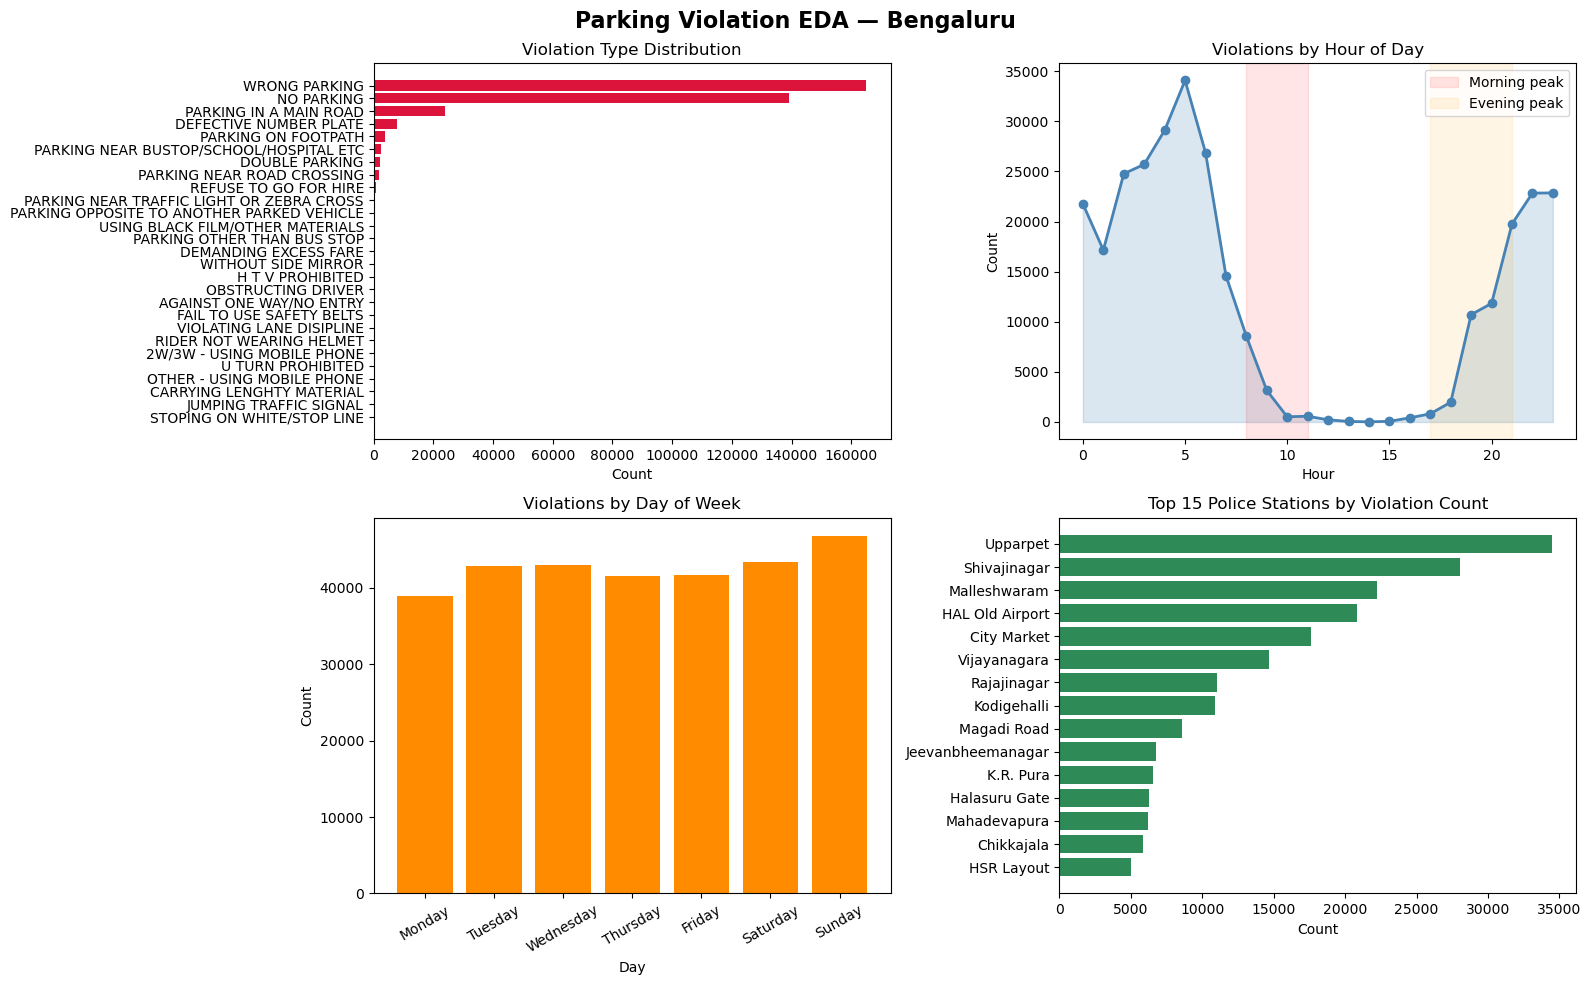

Saved: eda_overview.png

Running grid-based hotspot detection...
Hotspot grid cells (≥10 violations): 1643

Top 10 Hotspot Grid Cells:
 priority_rank  violation_count    lat    lon  peak_hour_share  near_junction  congestion_impact_score
             1             1422 12.977 77.576         0.165260            1.0                 0.833052
             2             1234 12.981 77.610         0.092382            1.0                 0.751904
             3              964 12.964 77.577         0.449170            1.0                 0.727653
             4             1020 12.973 77.579         0.089216            1.0                 0.675492
             5              891 12.977 77.577         0.173962            1.0                 0.646761
             6              766 12.984 77.604         0.246736            1.0                 0.617053
             7              716 12.965 77.539         0.248603            1.0                 0.599721
             8              787 12.974 77

In [5]:
import pandas as pd
import numpy as np
import ast
import folium
from folium.plugins import HeatMap, MarkerCluster
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("police.csv")

print(f"Total records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nNull counts:\n{df.isnull().sum()}")

df["created_datetime"] = pd.to_datetime(df["created_datetime"],format="mixed", utc=True)
df["closed_datetime"]  = pd.to_datetime(df["closed_datetime"], format="mixed", utc=True, errors="coerce")

df["hour"]       = df["created_datetime"].dt.hour
df["day_of_week"] = df["created_datetime"].dt.day_name()
df["date"]       = df["created_datetime"].dt.date
df["month"]      = df["created_datetime"].dt.month

def parse_violations(val):
    try:
        return ast.literal_eval(val) if pd.notna(val) else []
    except Exception:
        return []

df["violation_list"] = df["violation_type"].apply(parse_violations)

df_exploded = df.explode("violation_list").copy()
df_exploded["violation_list"] = df_exploded["violation_list"].str.strip()

df_approved = df[df["validation_status"] == "approved"].copy()
print(f"\nApproved records: {len(df_approved)} ({100*len(df_approved)/len(df):.1f}%)")

df_geo = df_approved.dropna(subset=["latitude", "longitude"]).copy()
print(f"Records with GPS: {len(df_geo)}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Parking Violation EDA — Bengaluru", fontsize=16, fontweight="bold")

all_violations = [v for sublist in df["violation_list"] for v in sublist]
viol_counts = Counter(all_violations)
viol_df = pd.DataFrame(viol_counts.items(), columns=["Violation", "Count"]).sort_values("Count", ascending=True)
axes[0, 0].barh(viol_df["Violation"], viol_df["Count"], color="crimson")
axes[0, 0].set_title("Violation Type Distribution")
axes[0, 0].set_xlabel("Count")

hour_counts = df.groupby("hour").size().reset_index(name="count")
axes[0, 1].plot(hour_counts["hour"], hour_counts["count"], marker="o", color="steelblue", linewidth=2)
axes[0, 1].fill_between(hour_counts["hour"], hour_counts["count"], alpha=0.2, color="steelblue")
axes[0, 1].set_title("Violations by Hour of Day")
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_ylabel("Count")
axes[0, 1].axvspan(8, 11, alpha=0.1, color="red", label="Morning peak")
axes[0, 1].axvspan(17, 21, alpha=0.1, color="orange", label="Evening peak")
axes[0, 1].legend()

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = df["day_of_week"].value_counts().reindex(dow_order)
axes[1, 0].bar(dow_counts.index, dow_counts.values, color="darkorange")
axes[1, 0].set_title("Violations by Day of Week")
axes[1, 0].set_xlabel("Day")
axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis="x", rotation=30)

top_stations = df["police_station"].value_counts().head(15)
axes[1, 1].barh(top_stations.index[::-1], top_stations.values[::-1], color="seagreen")
axes[1, 1].set_title("Top 15 Police Stations by Violation Count")
axes[1, 1].set_xlabel("Count")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_overview.png")

print("\nRunning grid-based hotspot detection...")

df_geo["lat_grid"] = (df_geo["latitude"]  / 0.001).round() * 0.001
df_geo["lon_grid"] = (df_geo["longitude"] / 0.001).round() * 0.001

grid = df_geo.groupby(["lat_grid", "lon_grid"]).agg(
    violation_count  = ("id", "count"),
    peak_hour_share  = ("hour", lambda x: ((x >= 8) & (x <= 11) | (x >= 17) & (x <= 21)).mean()),
    near_junction    = ("junction_name", lambda x: (x != "No Junction").mean()),
    top_violation    = ("violation_list", lambda x: Counter([v for sub in x for v in sub]).most_common(1)[0][0] if any(x) else "UNKNOWN"),
).reset_index()

grid = grid[grid["violation_count"] >= 10].copy()
print(f"Hotspot grid cells (≥10 violations): {len(grid)}")

grid = grid.rename(columns={"lat_grid": "lat", "lon_grid": "lon"})
cluster_stats = grid.copy()

def norm(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn + 1e-9)

cluster_stats["score_density"]  = norm(cluster_stats["violation_count"])
cluster_stats["score_peak"]     = norm(cluster_stats["peak_hour_share"])
cluster_stats["score_junction"] = norm(cluster_stats["near_junction"])

cluster_stats["congestion_impact_score"] = (
    0.5 * cluster_stats["score_density"] +
    0.3 * cluster_stats["score_junction"] +
    0.2 * cluster_stats["score_peak"]
)

cluster_stats = cluster_stats.sort_values("congestion_impact_score", ascending=False)
cluster_stats["priority_rank"] = range(1, len(cluster_stats) + 1)

print("\nTop 10 Hotspot Grid Cells:")
print(cluster_stats[["priority_rank","violation_count","lat","lon",
                       "peak_hour_share","near_junction",
                       "congestion_impact_score"]].head(10).to_string(index=False))

cluster_stats.to_csv("hotspot_clusters.csv", index=False)
print("Saved: hotspot_clusters.csv")

print("\nBuilding interactive heatmap...")

bengaluru_center = [12.9716, 77.5946]
m = folium.Map(location=bengaluru_center, zoom_start=12, tiles="CartoDB dark_matter")

heat_data = df_geo[["latitude", "longitude"]].values.tolist()
HeatMap(
    heat_data,
    radius=10,
    blur=8,
    max_zoom=14,
    gradient={"0.2": "blue", "0.5": "yellow", "0.8": "orange", "1.0": "red"},
    name="Violation Heatmap"
).add_to(m)

top_clusters = cluster_stats.head(20)
colors = ["red", "orange", "yellow", "lightgreen", "green"]

for _, row in top_clusters.iterrows():
    rank = int(row["priority_rank"])
    color = colors[min(rank - 1, 4)]

    popup_html = f"""
<b>🚨 Hotspot Rank #{rank}</b><br>
Violations: <b>{int(row['violation_count'])}</b><br>
Congestion Score: <b>{row['congestion_impact_score']:.3f}</b><br>
Near Junction: <b>{'Yes' if row['near_junction'] > 0.5 else 'No'}</b><br>
Peak Hour Share: <b>{row['peak_hour_share']:.1%}</b><br>
Top Violation: <b>{row['top_violation']}</b>
"""

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=10 + rank * 0.5,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"Rank #{rank} — Score: {row['congestion_impact_score']:.3f}"
    ).add_to(m)

junction_df = df_geo[df_geo["junction_name"] != "No Junction"].copy()
junction_counts = junction_df["junction_name"].value_counts().head(10)

mc = MarkerCluster(name="Junction Violations")
for junc, count in junction_counts.items():
    sample = junction_df[junction_df["junction_name"] == junc].iloc[0]
    folium.Marker(
        location=[sample["latitude"], sample["longitude"]],
        popup=f"<b>{junc}</b><br>Violations: {count}",
        tooltip=junc,
        icon=folium.Icon(color="purple", icon="warning-sign", prefix="glyphicon")
    ).add_to(mc)
mc.add_to(m)

folium.LayerControl().add_to(m)

legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:rgba(0,0,0,0.75); color:white; padding:12px 16px;
     border-radius:8px; font-size:13px; line-height:1.8;">
  <b>🗺️ Enforcement Priority</b><br>
  🔴 Rank 1–3 (Critical)<br>
  🟠 Rank 4–7 (High)<br>
  🟡 Rank 8–10 (Medium)<br>
  🟢 Rank 11+ (Low)<br>
  🟣 Junction hotspot
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save("parking_hotspot_map.html")
print("Saved: parking_hotspot_map.html  ← Open this in your browser!")

print("\n" + "="*60)
print("ENFORCEMENT PRIORITY REPORT — TOP 10 HOTSPOTS")
print("="*60)

for _, row in cluster_stats.head(10).iterrows():
    print(f"\n#{int(row['priority_rank'])}  Score: {row['congestion_impact_score']:.3f}")
    print(f"   Location : {row['lat']:.4f}, {row['lon']:.4f}")
    print(f"   Violations: {int(row['violation_count'])}")
    print(f"   Peak hours: {row['peak_hour_share']:.1%} of violations")
    print(f"   Junction:   {'Near junction' if row['near_junction'] > 0.5 else 'No junction'}")

print("\nDone! Files created:")
print("  📊 eda_overview.png")
print("  🗺️  parking_hotspot_map.html")
print("  📋 hotspot_clusters.csv")